In [1]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("weatherAUS.csv")

# clean column names
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()


Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [2]:
# check duplicates
print("Full row duplicates:", df.duplicated().sum())

# missing values (top)
missing = df.isna().sum().sort_values(ascending=False)
print("Top missing columns:")
print(missing.head(10))


Full row duplicates: 0
Top missing columns:
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
dtype: int64


In [3]:
# convert to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# create simple date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek


In [4]:
# remove rows with missing target
df = df.dropna(subset=["RainTomorrow"]).reset_index(drop=True)

# encode target: Yes=1, No=0
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})

print("Target distribution:")
print(df["RainTomorrow"].value_counts())


Target distribution:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [5]:
# RainToday has missing values, fill first then encode
df["RainToday"] = df["RainToday"].fillna("No")
df["RainToday"] = df["RainToday"].map({"Yes": 1, "No": 0})

# separate columns
target_col = "RainTomorrow"

# columns to drop (not needed after feature extraction)
drop_cols = ["Date"]

# categorical features
cat_cols = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"]

# numeric features
num_cols = [c for c in df.columns if c not in cat_cols + drop_cols + [target_col]]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))


Numeric cols: 20
Categorical cols: 4


In [6]:
# replace inf values if any
df = df.replace([np.inf, -np.inf], np.nan)

# fill numeric missing with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# fill categorical missing with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# final missing check
print("Missing values after preprocessing:", df.isna().sum().sum())



Missing values after preprocessing: 0


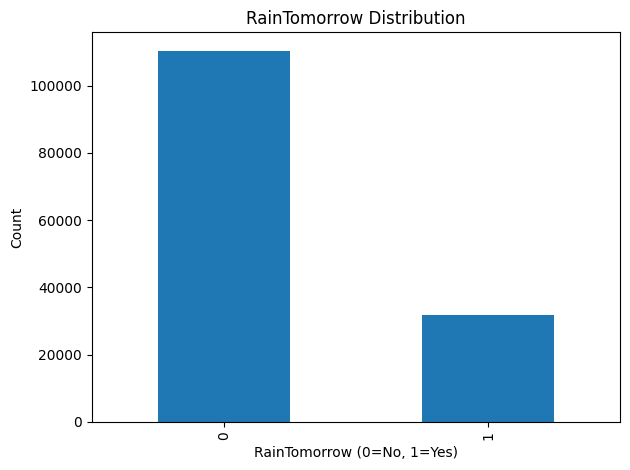

In [7]:
import matplotlib.pyplot as plt

# distribution of target variable
df["RainTomorrow"].value_counts().plot(kind="bar")

plt.title("RainTomorrow Distribution")
plt.xlabel("RainTomorrow (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# numeric columns only
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_eda.remove("RainTomorrow")

# correlation with target
corr_target = df[num_cols_eda + ["RainTomorrow"]].corr()["RainTomorrow"].drop("RainTomorrow")

# top correlated features
corr_target.sort_values(ascending=False).head(10)


,RainTomorrow
Humidity3pm,0.439741
RainToday,0.306555
Cloud3pm,0.295054
Humidity9am,0.255292
Cloud9am,0.248829
Rainfall,0.235087
WindGustSpeed,0.224766
WindSpeed9am,0.090446
WindSpeed3pm,0.086973
MinTemp,0.083701


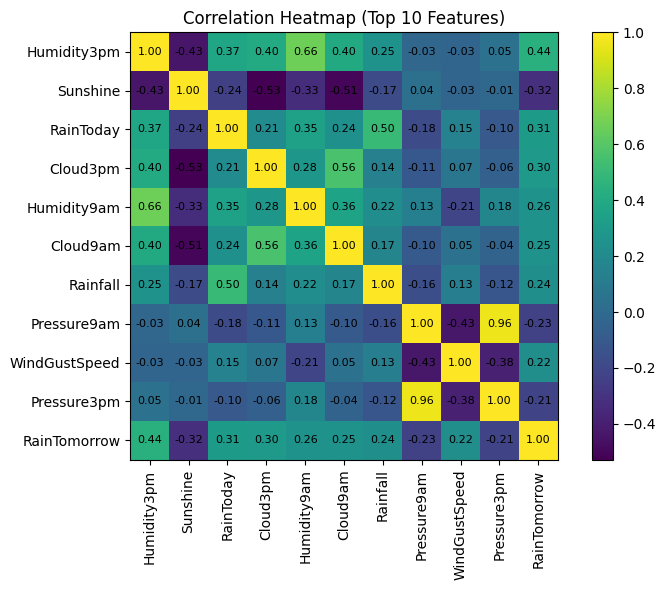

In [9]:
top10 = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()

corr_matrix = df[top10 + ["RainTomorrow"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# annotate values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap (Top 10 Features)")
plt.tight_layout()
plt.show()


In [10]:
# relationship between today's rain and tomorrow's rain
pd.crosstab(df["RainToday"], df["RainTomorrow"], normalize="index")


RainTomorrow,0,1
RainToday,,
0,0.843956,0.156044
1,0.535940,0.464060


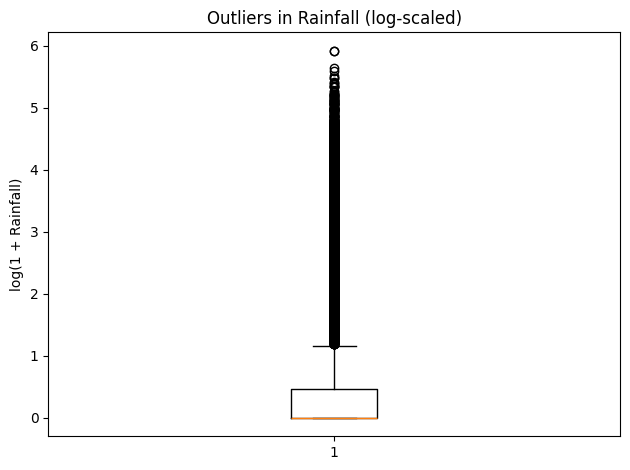

In [11]:
# log-scaled boxplot for rainfall
plt.boxplot(np.log1p(df["Rainfall"]))

plt.title("Outliers in Rainfall (log-scaled)")
plt.ylabel("log(1 + Rainfall)")
plt.tight_layout()
plt.show()


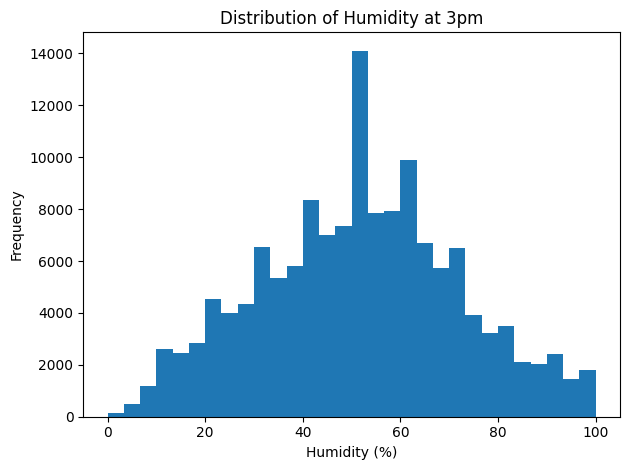

In [12]:
import matplotlib.pyplot as plt

# distribution of afternoon humidity
plt.hist(df["Humidity3pm"], bins=30)

plt.title("Distribution of Humidity at 3pm")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

# sort data by date to avoid using future data for training
df = df.sort_values("Date").reset_index(drop=True)

# define features and target
X = df.drop(columns=["RainTomorrow", "Date"])
y = df["RainTomorrow"]

# time-based split (80% train, 20% test)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Train shape: (113754, 24)
Test shape: (28439, 24)

Train target distribution:
RainTomorrow
0    0.775568
1    0.224432
Name: proportion, dtype: float64

Test target distribution:
RainTomorrow
0    0.776821
1    0.223179
Name: proportion, dtype: float64


In [14]:
from sklearn.preprocessing import LabelEncoder

# identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
Numerical columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [15]:
# label encode categorical columns
label_encoders = {}

for col in cat_cols:
    le_col = LabelEncoder()

    # fit on training data
    X_train[col] = le_col.fit_transform(X_train[col])

    # transform test data (handle unseen values safely)
    X_test[col] = X_test[col].map(
        lambda x: le_col.transform([x])[0] if x in le_col.classes_ else -1
    )

    label_encoders[col] = le_col

print("Label encoding completed")


/tmp/ipython-input-36359886.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = le_col.fit_transform(X_train[col])
/tmp/ipython-input-36359886.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].map(
/tmp/ipython-input-36359886.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

Label encoding completed


/tmp/ipython-input-36359886.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].map(


In [16]:
from sklearn.preprocessing import StandardScaler

# scale numerical columns
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Standard scaling applied")


Standard scaling applied


/tmp/ipython-input-1249076268.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
/tmp/ipython-input-1249076268.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


In [17]:
# class distribution before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())


Before SMOTE:
RainTomorrow
0    88224
1    25530
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE

# apply SMOTE to balance classes
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())

print("SMOTE train shape:", X_train_smote.shape)


After SMOTE:
RainTomorrow
1    88224
0    88224
Name: count, dtype: int64
SMOTE train shape: (176448, 24)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# random forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# train model
rf_model.fit(X_train_smote, y_train_smote)

# predictions
rf_pred = rf_model.predict(X_test)

# evaluation
print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.812
              precision    recall  f1-score   support

           0       0.90      0.85      0.88     22092
           1       0.57      0.68      0.62      6347

    accuracy                           0.81     28439
   macro avg       0.73      0.77      0.75     28439
weighted avg       0.83      0.81      0.82     28439



In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# xgboost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# train model
xgb_model.fit(X_train_smote, y_train_smote)

# predictions
xgb_pred = xgb_model.predict(X_test)

# evaluation
print("XGBoost Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 0.849
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     22092
           1       0.70      0.56      0.62      6347

    accuracy                           0.85     28439
   macro avg       0.79      0.75      0.76     28439
weighted avg       0.84      0.85      0.84     28439



In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# artificial neural network
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

# train model
ann_model.fit(X_train_smote, y_train_smote)

# predictions
ann_pred = ann_model.predict(X_test)

# evaluation
print("ANN Accuracy:", round(accuracy_score(y_test, ann_pred), 4))
print(classification_report(y_test, ann_pred))


ANN Accuracy: 0.7295
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     22092
           1       0.44      0.85      0.58      6347

    accuracy                           0.73     28439
   macro avg       0.69      0.77      0.69     28439
weighted avg       0.83      0.73      0.75     28439



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
